In [1]:
from pathlib import Path
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from pytorch_lightning.core.lightning import LightningModule
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/')

from utils.config_dataset import *
from utils.ClassDataset import MergedDataset
from utils.ClassSOM import VASO_CLF, VASO_PHYSIO_PRED, SOM_MTL

RANDOMSEED = 2024
torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

def mae_loss(x_, x, los=False):
    if los:
        loss = np.mean(np.abs(x - x_))
    else:
        mask_valid = np.where(x!=-1)
        loss = np.mean(np.abs(x[mask_valid] - x_[mask_valid]))
    return loss

In [2]:
model_path = 'models/VASO_CLF/CNN-196hidden-8som-3r-0.1dropout-8-0.0005/version_0'
model_file = os.path.join(model_path, "epoch28-val_loss0.80906.ckpt")
config_file = os.path.join(model_path, "model_config.p")

device = 'cuda'

 # load data
print("Loading dataset")
data_path = 'processed-merge/'
pid_valid = pickle.load(open(os.path.join(data_path, 'pid_valid_00.p'), 'rb'))
patient_info = pickle.load(open(os.path.join(data_path, 'patient_info.p'), 'rb'))
sample_dict = pickle.load(open(os.path.join(data_path, 'sample_dict_vasopressor.p'), 'rb'))
norm_params = pickle.load(open('processed-merge/norm_params_vasopressor.p', 'rb'))
norm_params_info = pickle.load(open('processed-merge/norm_params_info_vasopressor.p', 'rb'))

dischargestatus = []
for i in sample_dict:
    status = patient_info.loc[patient_info['patientid'] == sample_dict[i][1], 'discharge_status'].item()
    label = 1 if status == 'dead' else 0
    dischargestatus.append(label)
dischargestatus = np.array(dischargestatus)

selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']
selected_med = ['norepinephrine', 'epinephrine', 'dobutamine']
train_test_indices = pickle.load(open(os.path.join(data_path, 'train_test_split_vasopressor.p'), 'rb'))
sampleid_train, sampleid_test = train_test_indices['train'], train_test_indices['test']
sampleid_tr, sampleid_val = train_test_split(sampleid_train, test_size=0.2, random_state=RANDOMSEED,
                                   stratify=dischargestatus[sampleid_train])

dataset_val = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_val},
                              df_info=patient_info, norm=True, selected_physio=selected_physio,selected_med=selected_med)
dataset_test = MergedDataset(sample_dict={item[0]: item[1] for item in sample_dict.items() if item[0] in sampleid_test},
                              df_info=patient_info, norm=True, selected_physio=selected_physio,selected_med=selected_med)
loader_val = DataLoader(dataset_val, batch_size=16, shuffle=False, num_workers=32)
loader_test = DataLoader(dataset_test, batch_size=16, shuffle=False, num_workers=16)

# Train model
config = pickle.load(open(config_file, 'rb'))

model = VASO_CLF.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.to(device)
model.eval()

X_reconstructed = []
med_preds = []
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = X[k][j].to(device)
        else:
            X[k] = X[k].to(device)
    med_pred, X_ = model(X)
    X_reconstructed.append(X_.cpu().detach().numpy())
    med_preds.append(med_pred.cpu().detach().numpy())
    



Loading dataset


/home/kai/workspace/env/py38-torch/lib/python3.8/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
100%|████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 23.62it/s]


In [ ]:
med_label_gt = []
for sample in loader_test:
    med_label_gt.append(sample['med_label'].cpu().detach().numpy())
med_label_gt = np.concatenate(med_label_gt, axis=0)

In [3]:
X_reconstructed = np.concatenate(X_reconstructed, axis=0)
med_preds = np.concatenate(med_preds, axis=0)

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [5]:
# classification probability
med_prob = sigmoid(med_preds)
# binary classification label
probmax = med_prob.max(axis=1).reshape(-1, 1)
med_label = np.where(med_prob == probmax, 1, 0)

In [72]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_curve, precision_recall_curve

# 1 VS ALL

In [57]:
def binary_prob(arr, target):
    col_target = arr[:,target].reshape(-1,1)
    col_other = np.delete(arr, target, axis=1).sum(axis=1).reshape(-1,1)
    
    return col_target / (col_target + col_other)

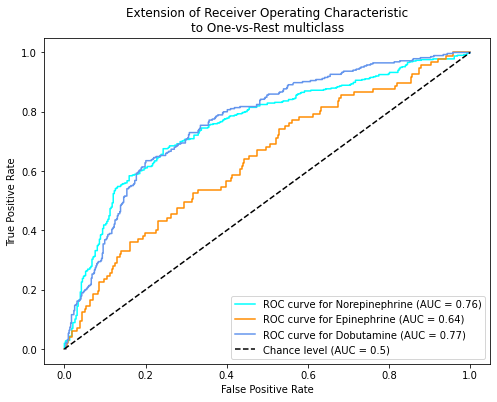

In [71]:
prob_norepinephrine = binary_prob(med_prob, 2)
med_label_gt_norepinephrine = med_label_gt[:, 2]

prob_epinephrine = binary_prob(med_prob, 1)
med_label_gt_epinephrine = med_label_gt[:, 1]

prob_dobutamine = binary_prob(med_prob, 0)
med_label_gt_dobutamine = med_label_gt[:, 0]


from itertools import cycle

fig, ax = plt.subplots(figsize=(8, 6))

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
names = ['Norepinephrine', 'Epinephrine', 'Dobutamine']
labels_gt = [med_label_gt_norepinephrine, med_label_gt_epinephrine, med_label_gt_dobutamine]
probs = [prob_norepinephrine, prob_epinephrine, prob_dobutamine]
for label, prob, name, color in zip(labels_gt, probs, names, colors):
    RocCurveDisplay.from_predictions(
        label,
        prob,
        name=f"ROC curve for {name}",
        color=color,
        ax=ax,
        plot_chance_level=(name=='Dobutamine'),
    )

_ = ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Extension of Receiver Operating Characteristic\nto One-vs-Rest multiclass",
)

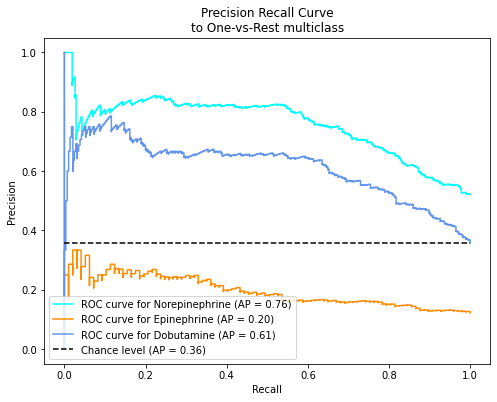

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
names = ['Norepinephrine', 'Epinephrine', 'Dobutamine']
labels_gt = [med_label_gt_norepinephrine, med_label_gt_epinephrine, med_label_gt_dobutamine]
probs = [prob_norepinephrine, prob_epinephrine, prob_dobutamine]
for label, prob, name, color in zip(labels_gt, probs, names, colors):
    PrecisionRecallDisplay.from_predictions(
        label,
        prob,
        name=f"ROC curve for {name}",
        color=color,
        ax=ax,
        plot_chance_level=(name=='Dobutamine'),
    )

_ = ax.set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision Recall Curve\nto One-vs-Rest multiclass",
)

# 1 VS 1

In [ ]:
from itertools import combinations

pair_list = list(combinations(np.unique(y), 2))
print(pair_list)

In [ ]:
pair_scores = []
mean_tpr = dict()

for ix, (label_a, label_b) in enumerate(pair_list):
    a_mask = y_test == label_a
    b_mask = y_test == label_b
    ab_mask = np.logical_or(a_mask, b_mask)

    a_true = a_mask[ab_mask]
    b_true = b_mask[ab_mask]

    idx_a = np.flatnonzero(label_binarizer.classes_ == label_a)[0]
    idx_b = np.flatnonzero(label_binarizer.classes_ == label_b)[0]

    fpr_a, tpr_a, _ = roc_curve(a_true, y_score[ab_mask, idx_a])
    fpr_b, tpr_b, _ = roc_curve(b_true, y_score[ab_mask, idx_b])

    mean_tpr[ix] = np.zeros_like(fpr_grid)
    mean_tpr[ix] += np.interp(fpr_grid, fpr_a, tpr_a)
    mean_tpr[ix] += np.interp(fpr_grid, fpr_b, tpr_b)
    mean_tpr[ix] /= 2
    mean_score = auc(fpr_grid, mean_tpr[ix])
    pair_scores.append(mean_score)

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.plot(
        fpr_grid,
        mean_tpr[ix],
        label=f"Mean {label_a} vs {label_b} (AUC = {mean_score :.2f})",
        linestyle=":",
        linewidth=4,
    )
    RocCurveDisplay.from_predictions(
        a_true,
        y_score[ab_mask, idx_a],
        ax=ax,
        name=f"{label_a} as positive class",
    )
    RocCurveDisplay.from_predictions(
        b_true,
        y_score[ab_mask, idx_b],
        ax=ax,
        name=f"{label_b} as positive class",
        plot_chance_level=True,
    )
    ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=f"{target_names[idx_a]} vs {label_b} ROC curves",
    )

print(f"Macro-averaged One-vs-One ROC AUC score:\n{np.average(pair_scores):.2f}")